In [1]:
!pip install statsforecast utilsforecast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 6.2 MB/s eta 0:00:00


In [2]:
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *



In [3]:
df=pd.read_csv('https://raw.githubusercontent.com/marcopeix/youtube_tutorials/refs/heads/main/data/daily_sales_french_bakery.csv',parse_dates=["ds"])
df=df.groupby("unique_id").filter(lambda x: len(x)>= 28)
df=df.drop(['unit_price'],axis=1)
df.head()


,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0


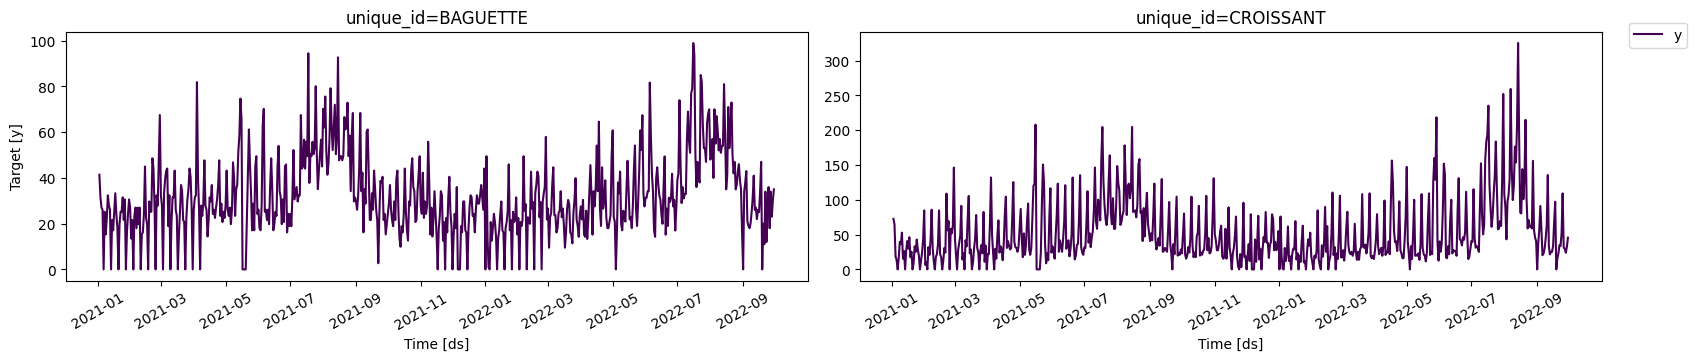

In [4]:
plot_series(df=df,ids=['BAGUETTE',"CROISSANT"],palette='viridis')


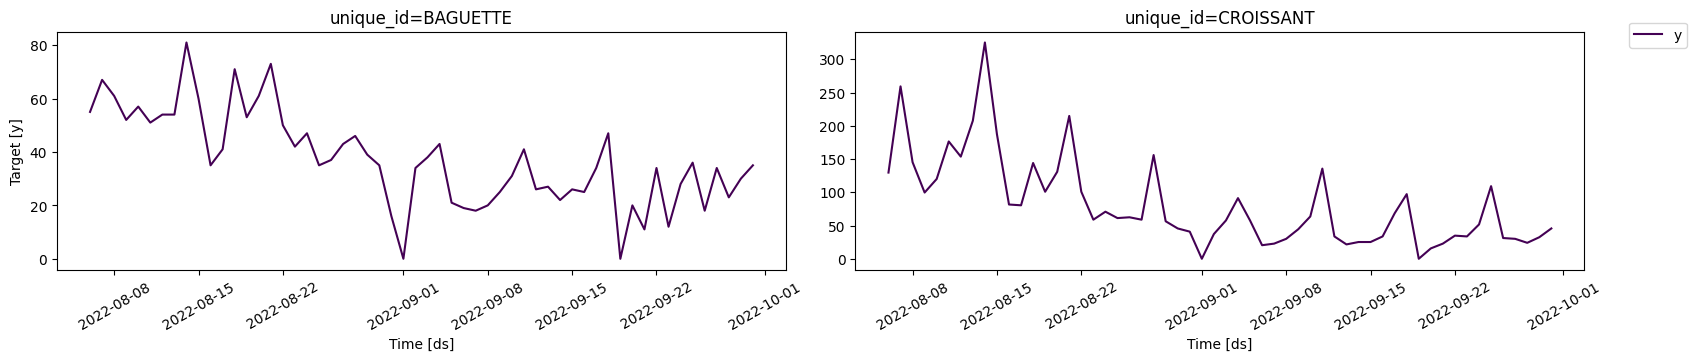

In [5]:
plot_series(df=df,ids=['BAGUETTE',"CROISSANT"],palette='viridis',max_insample_length=56)

In [6]:
from statsforecast import StatsForecast
from statsforecast.models import Naive ,HistoricAverage,WindowAverage, SeasonalNaive

In [7]:
horizon=7
model=[
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7)
]
sf=StatsForecast(models=model,freq='D',n_jobs=-1)
sf.fit(df=df)
preds=sf.predict(h=horizon)



In [8]:
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-29,10.0,8.974359,2.857143,0.0
1,12 MACARON,2022-09-30,10.0,8.974359,2.857143,0.0
2,12 MACARON,2022-10-01,10.0,8.974359,2.857143,10.0
3,12 MACARON,2022-10-02,10.0,8.974359,2.857143,0.0
4,12 MACARON,2022-10-03,10.0,8.974359,2.857143,0.0


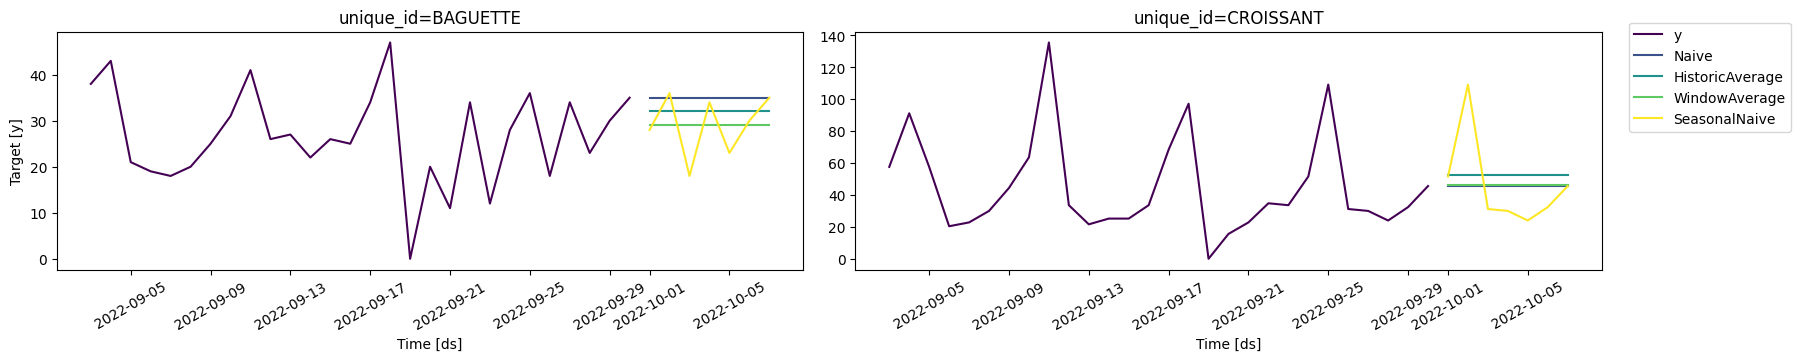

In [9]:
plot_series(
     df=df
     ,forecasts_df=preds
     ,ids=['BAGUETTE',"CROISSANT"]
     ,palette='viridis'
     ,max_insample_length=28

 )

In [10]:
#now we have predicted for the future but we dont have any data of the future to validate the prediction
#now we create test train split model for the prediction

test=df.groupby('unique_id').tail(7)
train=df.drop(test.index).reset_index(drop=True)
sf.fit(df=train)
preds=sf.predict(h=horizon)
eval_df=pd.merge(test,preds,'left',on=['ds','unique_id'])


In [11]:
evaluation=evaluate(
    eval_df,
    metrics=[mae],
)

evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,2.857143,6.961771,3.469388,4.285714
1,BAGUETTE,mae,17.142857,5.455193,7.877551,12.571429
2,BAGUETTE APERO,mae,0.000000,0.537572,0.642857,0.642857
3,BAGUETTE GRAINE,mae,9.800000,4.612271,2.942857,0.200000
4,BANETTE,mae,1.314286,5.421984,6.008163,7.885714


In [12]:
evaluation=evaluation.drop(['unique_id'],axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.107556,5.228439,5.011663,4.613636


['Naive', 'HistoricAverage', 'WindowAverage', 'SeasonalNaive']
[np.float64(6.107556080283353), np.float64(5.22843851951185), np.float64(5.011663012312363), np.float64(4.613636363636363)]


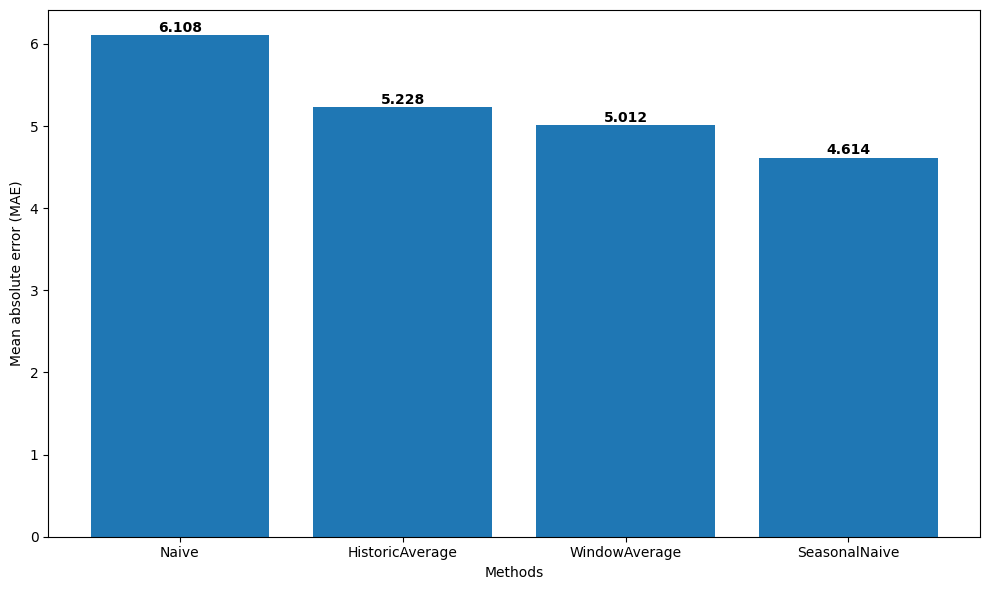

In [13]:
methods=evaluation.columns[1:].tolist()
print(methods)
values=evaluation.iloc[0,1:].tolist()
print(values)
plt.figure(figsize=(10,6))
bars=plt.bar(methods,values)
for bar,value in zip(bars,values):
    yval=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,yval+0.005,f'{value:.3f}',ha='center',va='bottom',fontweight='bold')


plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()
plt.show()

In [14]:
from statsforecast.models import AutoARIMA

#since arima is not a fast model we make a subset of the dataset on the basis of seriese
#
unique_ids=['BAGUETTE','CROISSANT']
small_train=train[train['unique_id'].isin(unique_ids)]
small_test=test[test['unique_id'].isin(unique_ids)]
models=[
    AutoARIMA(seasonal=False,alias='ARIMA')
    ,AutoARIMA(season_length=7,seasonal=True,alias='ARIMA_S')
]
sf=StatsForecast(models=models,freq='D',n_jobs=-1)
sf.fit(df=small_train)
arima_preds=sf.predict(h=horizon)
arima_eval_df=pd.merge(arima_preds,eval_df,'inner',['ds','unique_id'])
arima_eval=evaluate(arima_eval_df,metrics=[mae])
arima_eval


,unique_id,metric,ARIMA,ARIMA_S,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,BAGUETTE,mae,9.353153,7.449083,17.142857,5.455193,7.877551,12.571429
1,CROISSANT,mae,14.565395,10.359143,17.485714,22.618934,18.244898,12.857143


In [15]:
#only evaluating on the last 7 timesteps
arima_eval=arima_eval.drop(['unique_id'],axis=1).groupby('metric').mean().reset_index()
arima_eval

,metric,ARIMA,ARIMA_S,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,11.959274,8.904113,17.314286,14.037063,13.061224,12.714286


In [16]:
small_df=df[df['unique_id'].isin(unique_ids)]
models=[
    SeasonalNaive(season_length=7)
    ,AutoARIMA(season_length=7,seasonal=True,alias='ARIMA_S')
    ,AutoARIMA(seasonal=False,alias='ARIMA')
]
sf=StatsForecast(models=models,freq='D')
cv_df=sf.cross_validation(
    h=horizon,
    df=small_df,
    n_windows=8,
    step_size=horizon,
    refit=True,

)
cv_df.head()

,unique_id,ds,cutoff,y,SeasonalNaive,ARIMA_S,ARIMA
0,BAGUETTE,2022-08-06,2022-08-05,55.0,68.0,71.584713,71.355196
1,BAGUETTE,2022-08-07,2022-08-05,67.0,70.0,78.458883,70.337980
2,BAGUETTE,2022-08-08,2022-08-05,61.0,48.0,57.001732,61.195004
3,BAGUETTE,2022-08-09,2022-08-05,52.0,49.0,49.401144,52.649013
4,BAGUETTE,2022-08-10,2022-08-05,57.0,57.0,49.725278,47.785876


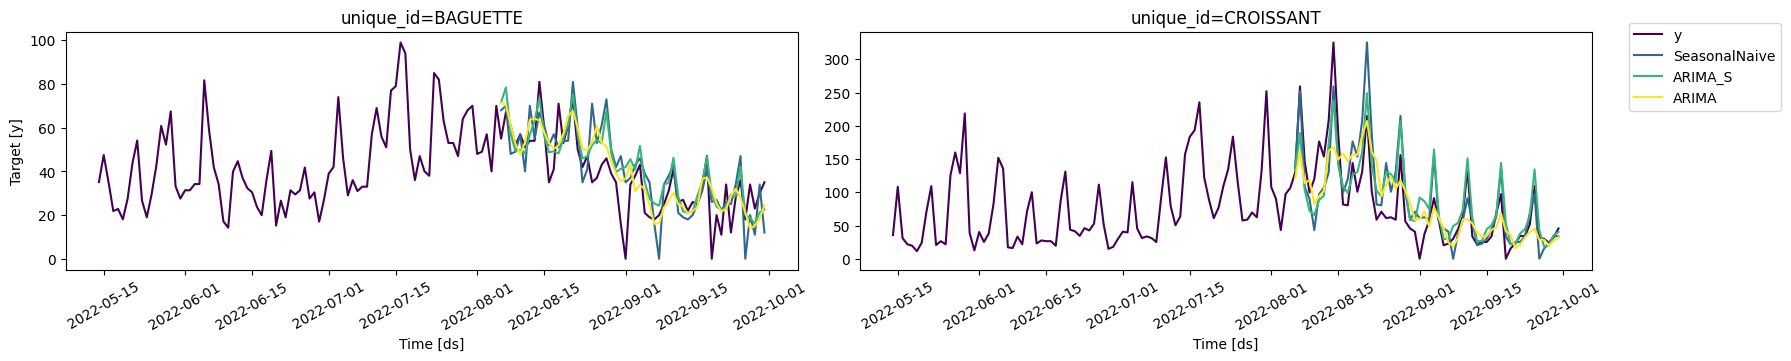

In [17]:
plot_series(
    df=small_df
    ,forecasts_df=cv_df.drop(['y','cutoff'],axis=1)
    ,ids=unique_ids
    ,palette='viridis'
    ,max_insample_length=140
)

In [18]:
cv_eval=evaluate(
    cv_df.drop(['cutoff'],axis=1),
    metrics=[mae]
)
cv_eval=cv_eval.drop(['unique_id'],axis=1).groupby('metric').mean().reset_index()
cv_eval

,metric,SeasonalNaive,ARIMA_S,ARIMA
0,mae,21.117857,19.281296,21.17093


In [19]:
#forecasting of the with exogenous features
df=pd.read_csv('https://raw.githubusercontent.com/marcopeix/youtube_tutorials/refs/heads/main/data/daily_sales_french_bakery.csv',parse_dates=["ds"])
df= df.groupby('unique_id').filter(lambda x: len(x)>=28)
df.head()



,unique_id,ds,y,unit_price
0,12 MACARON,2022-07-13,10.0,10.0
1,12 MACARON,2022-07-14,0.0,10.0
2,12 MACARON,2022-07-15,0.0,10.0
3,12 MACARON,2022-07-16,10.0,10.0
4,12 MACARON,2022-07-17,30.0,10.0


In [20]:
unique_ids=['BAGUETTE','CROISSANT']
small_df=df[df['unique_id'].isin(unique_ids)]
test=small_df.groupby('unique_id').tail(7)
train=small_df.drop(test.index).reset_index(drop=True)

In [21]:
#but with statical models we need ot get the future values for applying effective method
futr_exog_df=test.drop(['y'],axis=1)

In [22]:
models=[
    AutoARIMA(season_length=7,seasonal=True,alias='ARIMA_S_exog')
]
sf=StatsForecast(models=models,freq='D',n_jobs=-1)
sf.fit(df=train)
arimaex=sf.predict(h=horizon,X_df=futr_exog_df)

In [24]:
models=[
    AutoARIMA(season_length=7,alias='Sarima')
]
sf=StatsForecast(models=models,freq='D',n_jobs=-1)
sf.fit(df=train.drop(['unit_price'],axis=1))
arimapreds=sf.predict(h=horizon)

In [25]:
test_df=test.merge(arimaex,on=['ds','unique_id'],how='left')
test_df=test_df.merge(arimapreds,on=['ds','unique_id'],how='left')
test_df.head()

,unique_id,ds,y,unit_price,ARIMA_S_exog,Sarima
0,BAGUETTE,2022-09-24,28.0,1.0,28.898898,28.657114
1,BAGUETTE,2022-09-25,36.0,1.0,42.513264,42.182373
2,BAGUETTE,2022-09-26,18.0,1.0,20.423976,20.013652
3,BAGUETTE,2022-09-27,34.0,1.0,19.066264,18.646490
4,BAGUETTE,2022-09-28,23.0,1.0,16.468885,16.114925


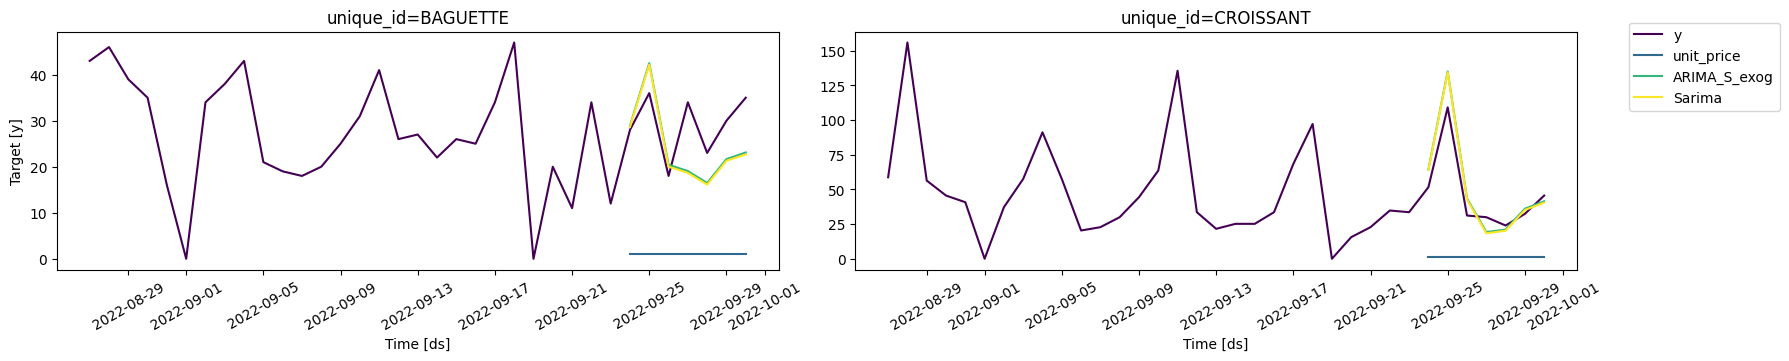

In [27]:
plot_series(
    df=train
    ,forecasts_df=test_df
    ,ids=unique_ids
    ,palette='viridis'
    ,max_insample_length=28
)